# Brazil Stocks — Fundamental Z-Score Analysis

This notebook demonstrates the full pipeline:
1. Fetch current fundamental data for all B3-listed equities (fundamentus.com.br)
2. Fetch 5-year historical OHLCV prices (Yahoo Finance)
3. Reconstruct historical P/E and P/S from quarterly financials
4. Compute time-series and cross-sectional Z-scores
5. Visualise and screen for statistically cheap stocks

In [ ]:

import sys, os, warnings
warnings.filterwarnings('ignore')
sys.path.insert(0, os.path.abspath('..'))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', 20)
pd.set_option('display.float_format', '{:.2f}'.format)
sns.set_theme(style='whitegrid', palette='muted', font_scale=0.85)
plt.rcParams['figure.dpi'] = 110

# ── Config ────────────────────────────────────────────────────────────────────
DB_PATH, PRICE_PERIOD, WINDOW_YEARS = '../data/brazil_stocks.db', '5y', 5
ZSCORE_THRESHOLD, TOP_N_HEATMAP, TOP_N_RANKING = -1.0, 25, 15
# DCF assumptions (nominal BRL). See brazil_stocks/analysis/dcf.py for caveats.
DISCOUNT_RATE, TERMINAL_GROWTH = 0.13, 0.04
METRICS = ['pl', 'pvp', 'ev_ebitda', 'ps', 'dy', 'roe', 'net_margin', 'debt_equity']
METRIC_LABELS = {
    'pl': 'P/L', 'pvp': 'P/VP', 'ev_ebitda': 'EV/EBITDA', 'ev_ebit': 'EV/EBIT',
    'p_ebit': 'P/EBIT', 'ps': 'P/Receita', 'dy': 'Div. Yield',
    'roe': 'ROE', 'roic': 'ROIC', 'gross_margin': 'Margem Bruta',
    'ebit_margin': 'Margem EBIT', 'net_margin': 'Margem Líq.',
    'debt_equity': 'Dív/PL', 'current_ratio': 'Liq. Corr.',
    'fcf_per_share': 'FCF/Ação', 'intrinsic_value': 'Valor Intrínseco',
    'margin_of_safety': 'Margem Segurança', 'quality_score': 'Qualidade',
    'moat_score': 'Moat',
}

# ── Orchestrator ──────────────────────────────────────────────────────────────
from brazil_stocks.orchestrator import StockAnalysisOrchestrator
from brazil_stocks.fetchers.fundamentus import FundamentusFetcher
from brazil_stocks.analysis.zscore import ZScoreAnalyzer, FUNDAMENTAL_METRICS

orc = StockAnalysisOrchestrator(
    db_path=DB_PATH, price_period=PRICE_PERIOD, window_years=WINDOW_YEARS,
    discount_rate=DISCOUNT_RATE, terminal_growth=TERMINAL_GROWTH,
)
print('Setup OK |', orc.db.summary())


Setup OK | {'stocks': np.int64(943), 'fundamental_snapshots': np.int64(85760), 'price_history': np.int64(1204818), 'zscore_results': np.int64(40254)}


In [2]:

fetcher = FundamentusFetcher(include_fiis=False, include_bdrs=False)
print('Fetching fundamentals …')
fund_df = fetcher.fetch()
orc.db.upsert_stocks(fetcher.to_stocks(fund_df))
orc.db.upsert_fundamental_snapshots(fetcher.to_snapshots(fund_df))
print(f'✓ {len(fund_df)} equities | {orc.db.summary()}')
fund_df[[m for m in METRICS if m in fund_df.columns]].describe().T.round(2)


Fetching fundamentals …
✓ 943 equities | {'stocks': np.int64(943), 'fundamental_snapshots': np.int64(86703), 'price_history': np.int64(1204818), 'zscore_results': np.int64(40254)}


,count,mean,std,min,25%,50%,75%,max
pl,943.00,-129.56,4334.82,-132993.00,-0.18,4.92,13.23,2705.29
pvp,943.00,1539.08,32619.91,-359.15,0.06,0.93,1.98,723708.00
ev_ebitda,943.00,30.90,1209.25,-7466.35,0.00,4.22,8.43,36193.10
ps,943.00,697.74,20996.20,-959.61,0.04,0.54,1.49,644756.00
dy,943.00,3.88,39.73,0.00,0.00,0.00,2.08,1202.89
roe,943.00,2872.32,62751.28,-15969.00,0.10,9.64,19.50,1363200.00
net_margin,943.00,-33074.50,1010247.90,-31023100.00,-2.46,2.32,11.43,28534.50
debt_equity,936.00,3497.69,75200.17,-4771.00,-14.25,8.50,83.00,1627700.00


In [3]:

from brazil_stocks.fetchers.ibov import get_ibov_tickers
ibov_tickers   = get_ibov_tickers()
all_tickers    = orc.db.get_all_tickers()
active_tickers = ibov_tickers + [t for t in all_tickers if t not in set(ibov_tickers)]
# active_tickers = ibov_tickers   # IBOV-only mode

print(f'IBOV: {len(ibov_tickers)} | Full B3: {len(all_tickers)} | Downloading {len(active_tickers)} …')
price_df   = orc._fetch_prices_with_progress(active_tickers, PRICE_PERIOD)
price_bars = orc.yf.to_price_bars(price_df)
n_stored   = orc.db.upsert_price_bars(price_bars)
print(f'✓ {len(price_df):,} bars downloaded | {n_stored:,} stored | {orc.db.summary()}')


IBOV: 81 | Full B3: 943 | Downloading 957 …


Fetching prices:   0%|          | 0/20 [00:00<?, ?batch/s]$CPLE6.SA: possibly delisted; no price data found  (period=5y) (Yahoo error = "No data found, symbol may be delisted")
$EMBR3.SA: possibly delisted; no price data found  (period=5y) (Yahoo error = "No data found, symbol may be delisted")
HTTP Error 404: {"quoteSummary":{"result":null,"error":{"code":"Not Found","description":"Quote not found for symbol: ELET6.SA"}}}
$IGTA3.SA: possibly delisted; no price data found  (period=5y) (Yahoo error = "No data found, symbol may be delisted")
$CIEL3.SA: possibly delisted; no price data found  (period=5y) (Yahoo error = "No data found, symbol may be delisted")
$GNDI3.SA: possibly delisted; no price data found  (period=5y) (Yahoo error = "No data found, symbol may be delisted")
$ENBR3.SA: possibly delisted; no price data found  (period=5y) (Yahoo error = "No data found, symbol may be delisted")
$JBSS3.SA: possibly delisted; no price data found  (period=5y) (Yahoo error = "No data found, sym

✓ 1,193,929 bars downloaded | 1,193,929 stored | {'stocks': np.int64(943), 'fundamental_snapshots': np.int64(86703), 'price_history': np.int64(1207689), 'zscore_results': np.int64(40254)}


In [4]:

hist_tickers = ibov_tickers   # IBOV only — best data quality
print(f'Computing historical P/E & P/S for {len(hist_tickers)} tickers …')
n_hist = orc.metrics_calc.compute_and_store(hist_tickers)
print(f'✓ {n_hist:,} rows stored')


Computing historical P/E & P/S for 81 tickers …


AZUL4: no quarterly income data — skipping historical metrics
BRDT3: no quarterly income data — skipping historical metrics
BRFS3: no quarterly income data — skipping historical metrics
BRML3: no quarterly income data — skipping historical metrics
BTOW3: no quarterly income data — skipping historical metrics
CCRO3: no quarterly income data — skipping historical metrics
CIEL3: no quarterly income data — skipping historical metrics
CPLE6: no quarterly income data — skipping historical metrics
CRFB3: no quarterly income data — skipping historical metrics
ELET3: no quarterly income data — skipping historical metrics
ELET6: no quarterly income data — skipping historical metrics
EMBR3: no quarterly income data — skipping historical metrics
ENBR3: no quarterly income data — skipping historical metrics
GNDI3: no quarterly income data — skipping historical metrics
GOLL4: no quarterly income data — skipping historical metrics
HGTX3: no quarterly income data — skipping historical metrics
IGTA3: n

✓ 11,922 rows stored


In [5]:

import importlib, brazil_stocks.analysis.zscore as _z
importlib.reload(_z)
from brazil_stocks.analysis.zscore import ZScoreAnalyzer
orc.zscore_analyzer = ZScoreAnalyzer(orc.db, window_years=WINDOW_YEARS)

zscore_results = orc.zscore_analyzer.compute_all(metrics=METRICS, group_by_sector=False)
snap_date = orc.zscore_analyzer._latest_snapshot_date()
zdf = orc.db.get_zscore_results(snapshot_date=snap_date.isoformat())
print(f'✓ {len(zscore_results)} Z-scores | {snap_date} | '
      f'min_obs={orc.zscore_analyzer.min_observations}, '
      f'cap=±{orc.zscore_analyzer.zscore_cap}')
zdf.dropna(subset=['cross_sectional_zscore']).sort_values('cross_sectional_zscore', key=abs, ascending=False).head(8)


✓ 7600 Z-scores | 2026-06-03 | min_obs=20, cap=±5.0


,id,ticker,snapshot_date,metric,time_series_zscore,cross_sectional_zscore,window_years
4352,168056,LUPA3,2026-06-03,debt_equity,NaN,5.00,5
4359,166156,LUPA3,2026-06-03,roe,NaN,-5.00,5
36,161551,ABYA3,2026-06-03,pl,NaN,-5.00,5
4388,161188,MAGG3,2026-06-03,pl,NaN,-5.00,5
6211,166846,SJOS3,2026-06-03,net_margin,NaN,-5.00,5
71,166419,ADMF3,2026-06-03,roe,NaN,5.00,5
6219,166823,SJOS4,2026-06-03,net_margin,NaN,-5.00,5
1778,163599,CGOS4,2026-06-03,ev_ebitda,NaN,-5.00,5


In [6]:

# ── Growth analysis: EPS/revenue YoY, trend slope, consistency ───────────────
import importlib, brazil_stocks.analysis.growth as _g
importlib.reload(_g)
from brazil_stocks.analysis.growth import GrowthAnalyzer, GROWTH_METRICS, COMPOSITE_METRIC

orc.growth_analyzer = GrowthAnalyzer(orc.db, min_ttm_points=2, lookback_points=8, min_metrics_for_composite=4)
growth_df = orc.growth_analyzer.compute_and_store(ibov_tickers, snapshot_date=snap_date)

print(f'✓ growth metrics computed for {len(growth_df)} tickers')
growth_df[['ticker', 'eps_qoq', 'revenue_qoq', 'eps_yoy', 'eps_slope',
           'positive_qtr_ratio', COMPOSITE_METRIC]] \
    .dropna(subset=[COMPOSITE_METRIC]).sort_values(COMPOSITE_METRIC, ascending=False).head(10).round(3)


✓ growth metrics computed for 71 tickers


,ticker,eps_qoq,revenue_qoq,eps_yoy,eps_slope,positive_qtr_ratio,growth_score
58,RENT3,1.33,0.38,1.33,NaN,NaN,1.75
57,RAIL3,0.64,0.35,3.56,0.64,1.00,1.20
36,HYPE3,1.27,0.36,1.27,NaN,NaN,1.12
68,VIVT3,0.48,0.38,1.65,0.46,1.00,1.01
14,COGN3,0.10,0.67,1.36,0.37,1.00,0.92
65,UGPA3,0.42,0.42,1.13,0.36,1.00,0.84
34,HAPV3,4.83,0.45,0.62,-0.32,0.50,0.73
66,USIM5,1.07,0.28,1.07,NaN,NaN,0.64
52,PETR3,0.19,0.39,1.06,0.33,1.00,0.63
20,CVCB3,3.75,0.33,-0.59,0.59,0.50,0.62


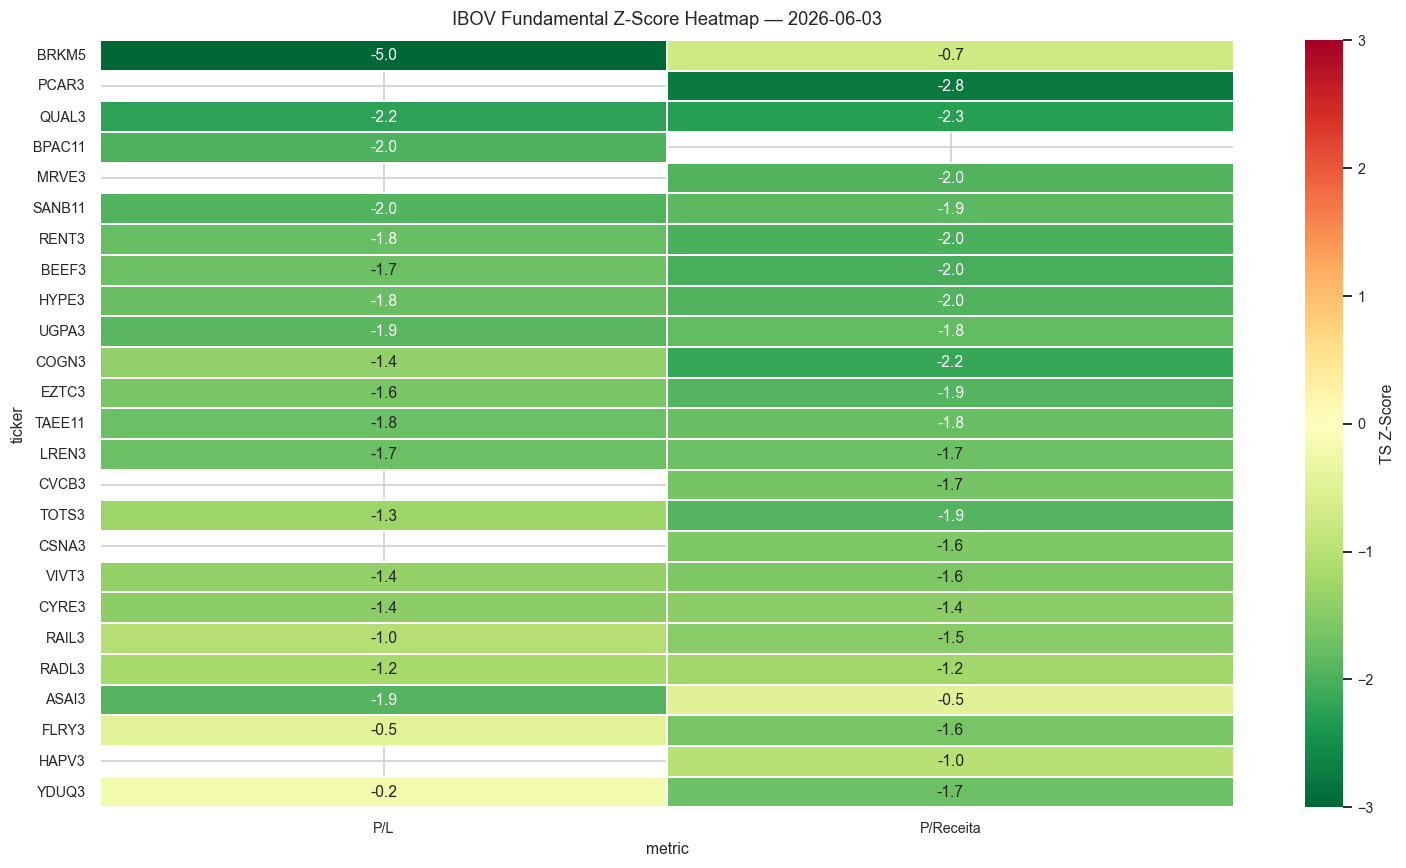

In [7]:

_hm = orc.get_heatmap_data(
    metrics=[m for m in METRICS if m in zdf['metric'].unique()],
    score_type='time_series_zscore', top_n=500,
)
_hm = _hm[_hm.index.isin(ibov_tickers)].head(TOP_N_HEATMAP)

if _hm.empty:
    print('No data — run pipeline first.')
else:
    fig, ax = plt.subplots(figsize=(14, max(5, len(_hm) * 0.32)))
    sns.heatmap(
        _hm.rename(columns=METRIC_LABELS), ax=ax,
        cmap='RdYlGn_r', center=0, annot=True, fmt='.1f',
        linewidths=0.3, cbar_kws={'label': 'TS Z-Score'}, vmin=-3, vmax=3,
    )
    ax.set_title(f'IBOV Fundamental Z-Score Heatmap — {snap_date}', fontsize=12, pad=10)
    plt.tight_layout()
    plt.show()


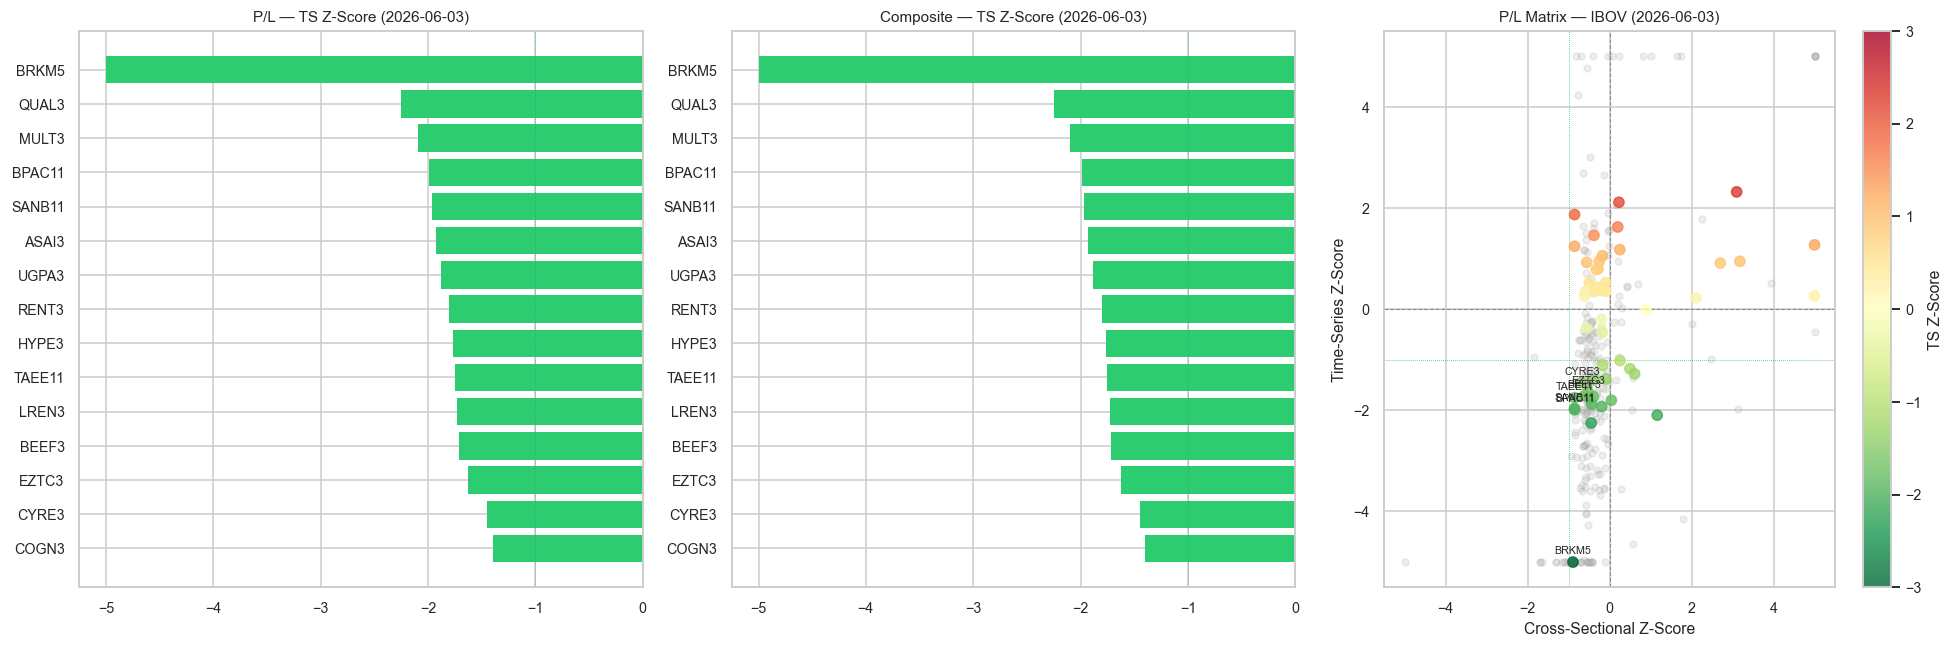

In [8]:

_ibov = set(ibov_tickers)

def _bar(ax, df, col, title):
    colors = ['#2ecc71' if v <= 0 else '#e74c3c' for v in df[col]]
    ax.barh(df['ticker'], df[col], color=colors, edgecolor='none')
    ax.axvline(0, color='#555', lw=0.8, ls='--')
    ax.axvline(-1, color='#27ae60', lw=0.5, ls=':')
    ax.invert_yaxis()
    ax.set_title(title, fontsize=10)

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Panel 1 — P/L time-series ranking (IBOV)
df_pl = orc.get_zscore_ranking('pl', 'time_series_zscore', top_n=200)
df_pl = df_pl[df_pl['ticker'].isin(_ibov)].head(TOP_N_RANKING)
_bar(axes[0], df_pl, 'time_series_zscore', f'P/L — TS Z-Score ({snap_date})')

# Panel 2 — Composite ranking (IBOV)
comp = orc.get_composite_ranking(['pl', 'pvp', 'ev_ebitda'], 'time_series_zscore')
comp = comp[comp['ticker'].isin(_ibov)].head(TOP_N_RANKING)
_bar(axes[1], comp, 'composite_zscore', f'Composite — TS Z-Score ({snap_date})')

# Panel 3 — P/L scatter TS vs CS (IBOV highlighted)
df_sc = zdf[zdf['metric'] == 'pl'].dropna(subset=['time_series_zscore', 'cross_sectional_zscore'])
df_all  = df_sc[~df_sc['ticker'].isin(_ibov)]
df_ibov = df_sc[df_sc['ticker'].isin(_ibov)]
ax = axes[2]
ax.scatter(df_all['cross_sectional_zscore'], df_all['time_series_zscore'],
           alpha=0.2, s=20, c='#aaa')
sc = ax.scatter(df_ibov['cross_sectional_zscore'], df_ibov['time_series_zscore'],
                alpha=0.8, s=45, c=df_ibov['time_series_zscore'],
                cmap='RdYlGn_r', vmin=-3, vmax=3, zorder=3)
plt.colorbar(sc, ax=ax, label='TS Z-Score')
cheap = df_ibov[
    (df_ibov['time_series_zscore'] < -1) & (df_ibov['cross_sectional_zscore'] < -0.5)
].head(8)
for _, r in cheap.iterrows():
    ax.annotate(r['ticker'], (r['cross_sectional_zscore'], r['time_series_zscore']),
                fontsize=7, ha='center', va='bottom', xytext=(0, 4), textcoords='offset points')
ax.axhline(0, color='#888', lw=0.7, ls='--'); ax.axvline(0, color='#888', lw=0.7, ls='--')
ax.axhline(-1, color='#27ae60', lw=0.5, ls=':'); ax.axvline(-1, color='#27ae60', lw=0.5, ls=':')
ax.set_xlabel('Cross-Sectional Z-Score'); ax.set_ylabel('Time-Series Z-Score')
ax.set_title(f'P/L Matrix — IBOV ({snap_date})', fontsize=10)

plt.tight_layout()
plt.show()


In [9]:

from datetime import date, timedelta
from brazil_stocks.fetchers.ibov import get_ibov_tickers as _get_ibov

# ── Universe filter ───────────────────────────────────────────────────────────
# By default show IBOV stocks only — the 81 most liquid names on B3.
# Uncomment the second option to widen to all actively-traded stocks
# (tickers that have a price bar in the last 10 calendar days).
USE_IBOV_ONLY = True

if USE_IBOV_ONLY:
    _ibov = ibov_tickers if 'ibov_tickers' in dir() else _get_ibov()
    _universe = set(_ibov)
else:
    _cutoff = (date.today() - timedelta(days=10)).isoformat()
    _universe = set(
        orc.db.query(
            f"SELECT DISTINCT ticker FROM price_history WHERE date >= '{_cutoff}'"
        )["ticker"].tolist()
    )

screened = orc.screen_stocks(
    zscore_threshold=ZSCORE_THRESHOLD,
    metrics=['pl', 'pvp', 'ev_ebitda'],   # valuation multiples only
    score_type='time_series_zscore',
    require_all=False,                     # True = cheap on ALL three metrics
)

screened = screened[screened["ticker"].isin(_universe)].copy()

# Already sorted by composite_zscore ascending (most undervalued first)
TOP_SCREEN = 20
print(f'Universe: {"IBOV" if USE_IBOV_ONLY else "all active"} '
      f'| Stocks below Z-score {ZSCORE_THRESHOLD}: {len(screened)}  →  top {TOP_SCREEN}')
screened.head(TOP_SCREEN).round(2)


Universe: IBOV | Stocks below Z-score -1.0: 20  →  top 20


metric,ticker,pl,composite_zscore
12,BRKM5,-5.00,-5.00
86,QUAL3,-2.25,-2.25
93,MULT3,-2.10,-2.10
104,BPAC11,-1.99,-1.99
109,SANB11,-1.96,-1.96
113,ASAI3,-1.93,-1.93
116,UGPA3,-1.88,-1.88
120,RENT3,-1.80,-1.80
124,HYPE3,-1.77,-1.77
126,TAEE11,-1.75,-1.75


GARP candidates (value≤-0.5, growth≥0.5): 3


,ticker,ev_ebitda,pl,pvp,value_zscore,growth_score,alpha_score
0,HAPV3,-0.41,-1.50,-0.88,-0.93,0.73,1.66
1,COGN3,-0.58,-0.37,-0.76,-0.57,0.91,1.49
2,CVCB3,-0.65,-1.20,-0.01,-0.62,0.62,1.24


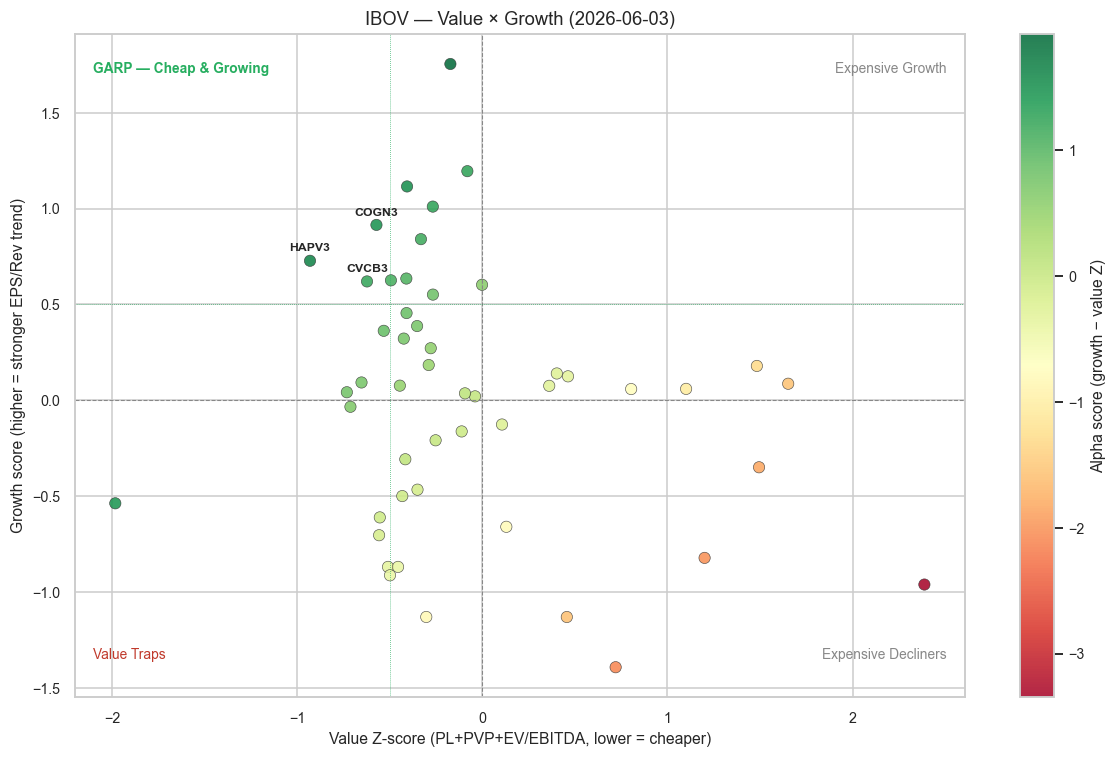

In [10]:

# ── GARP scan: cheap & growing (low value Z + high growth score) ─────────────
VALUE_THRESHOLD, GROWTH_THRESHOLD = -0.5, 0.5

garp = orc.screen_quality_value(
    value_metrics=['pl', 'pvp', 'ev_ebitda'],
    value_threshold=VALUE_THRESHOLD,
    growth_threshold=GROWTH_THRESHOLD,
    score_type='cross_sectional_zscore',
    require_growth=True,
)
print(f'GARP candidates (value≤{VALUE_THRESHOLD}, growth≥{GROWTH_THRESHOLD}): {len(garp)}')
display(garp.head(15).round(2))

# 4-quadrant value × growth chart for IBOV
_v = (
    orc.db.get_zscore_results(snapshot_date=snap_date.isoformat())
    .pivot_table(index='ticker', columns='metric',
                 values='cross_sectional_zscore', aggfunc='first')
)
_v['value_zscore'] = _v[['pl', 'pvp', 'ev_ebitda']].mean(axis=1)
_g_cs = (
    orc.db.get_zscore_results(snapshot_date=snap_date.isoformat())
    .query('metric == @COMPOSITE_METRIC')
    .set_index('ticker')['cross_sectional_zscore']
)
plot_df = _v[['value_zscore']].join(_g_cs.rename('growth_score'), how='inner').dropna()
plot_df = plot_df[plot_df.index.isin(ibov_tickers)]

fig, ax = plt.subplots(figsize=(11, 7))
sc = ax.scatter(plot_df['value_zscore'], plot_df['growth_score'],
                c=plot_df['growth_score'] - plot_df['value_zscore'],
                cmap='RdYlGn', s=55, alpha=0.85, edgecolor='#333', linewidth=0.4)
plt.colorbar(sc, ax=ax, label='Alpha score (growth − value Z)')

# Quadrant guides
ax.axhline(0, color='#888', lw=0.7, ls='--'); ax.axvline(0, color='#888', lw=0.7, ls='--')
ax.axhline(GROWTH_THRESHOLD, color='#27ae60', lw=0.5, ls=':')
ax.axvline(VALUE_THRESHOLD,  color='#27ae60', lw=0.5, ls=':')

# Label the GARP quadrant (cheap & growing)
garp_pts = plot_df[(plot_df['value_zscore'] <= VALUE_THRESHOLD) &
                   (plot_df['growth_score'] >= GROWTH_THRESHOLD)]
for tkr, row in garp_pts.iterrows():
    ax.annotate(tkr, (row['value_zscore'], row['growth_score']),
                fontsize=8, ha='center', va='bottom',
                xytext=(0, 5), textcoords='offset points', weight='bold')

# Quadrant titles
xl, xr = ax.get_xlim(); yb, yt = ax.get_ylim()
ax.text(xl + 0.1, yt - 0.2, 'GARP — Cheap & Growing',  color='#27ae60', fontsize=9, weight='bold')
ax.text(xr - 0.1, yt - 0.2, 'Expensive Growth',         color='#888',   fontsize=9, ha='right')
ax.text(xl + 0.1, yb + 0.2, 'Value Traps',              color='#c0392b', fontsize=9)
ax.text(xr - 0.1, yb + 0.2, 'Expensive Decliners',      color='#888',   fontsize=9, ha='right')

ax.set_xlabel('Value Z-score (PL+PVP+EV/EBITDA, lower = cheaper)')
ax.set_ylabel('Growth score (higher = stronger EPS/Rev trend)')
ax.set_title(f'IBOV — Value × Growth ({snap_date})', fontsize=12)
plt.tight_layout(); plt.show()


In [11]:
# ── Full alpha ranking — every IBOV stock with value & growth Z ──────────────
# `plot_df` was built in the GARP scan cell above and contains every IBOV
# ticker that has both a value_zscore and a growth_score on the latest snap.
from IPython.display import HTML
from matplotlib import colormaps
from matplotlib.colors import Normalize, to_hex

full_rank = plot_df.copy()
full_rank['alpha_score'] = full_rank['growth_score'] - full_rank['value_zscore']
full_rank['GARP'] = (
    (full_rank['value_zscore'] <= VALUE_THRESHOLD) &
    (full_rank['growth_score'] >= GROWTH_THRESHOLD)
)
full_rank = (
    full_rank.sort_values('alpha_score', ascending=False)
             .reset_index()
             .rename(columns={'ticker': 'Ticker',
                              'value_zscore':  'Value Z',
                              'growth_score':  'Growth Z',
                              'alpha_score':   'Alpha'})
             .round(2)
)
full_rank.index += 1
full_rank.index.name = 'rank'

n_garp = int(full_rank['GARP'].sum())
print(f'Alpha ranking — {snap_date}  |  {len(full_rank)} IBOV stocks  |  {n_garp} pass GARP gates')

# ── Build a coloured HTML table without pandas Styler / jinja2 ───────────────
def _grad(series, cmap_name):
    vals = series.astype(float)
    vmax = float(np.nanmax(np.abs(vals)))
    norm = Normalize(vmin=-vmax, vmax=vmax)
    cmap = colormaps[cmap_name]
    return [to_hex(cmap(norm(v))) for v in vals]

colors = {
    'Alpha':    _grad(full_rank['Alpha'],    'RdYlGn'),
    'Value Z':  _grad(full_rank['Value Z'],  'RdYlGn_r'),
    'Growth Z': _grad(full_rank['Growth Z'], 'RdYlGn'),
}

cols = ['Ticker', 'Value Z', 'Growth Z', 'Alpha', 'GARP']
head = ''.join(f'<th style="padding:4px 10px;text-align:right;'
               f'border-bottom:1px solid #999">{c}</th>' for c in ['rank', *cols])
rows = []
for i, (rank, r) in enumerate(full_rank[cols].iterrows()):
    cells = [f'<td style="padding:3px 10px;text-align:right;color:#666">{rank}</td>']
    for c in cols:
        v = r[c]
        if c in colors:
            bg = colors[c][i]
            cells.append(f'<td style="padding:3px 10px;text-align:right;'
                         f'background:{bg}">{v:.2f}</td>')
        elif c == 'GARP':
            if v:
                cells.append('<td style="padding:3px 10px;text-align:center;'
                             'font-weight:bold;color:#1b7a35">✓</td>')
            else:
                cells.append('<td style="padding:3px 10px;text-align:center;color:#bbb">·</td>')
        else:
            cells.append(f'<td style="padding:3px 10px;font-weight:600">{v}</td>')
    rows.append('<tr>' + ''.join(cells) + '</tr>')

html = (f'<table style="border-collapse:collapse;font-family:system-ui,sans-serif;'
        f'font-size:12px"><thead><tr>{head}</tr></thead>'
        f'<tbody>{"".join(rows)}</tbody></table>')
display(HTML(html))


Alpha ranking — 2026-06-03  |  50 IBOV stocks  |  3 pass GARP gates


rank,Ticker,Value Z,Growth Z,Alpha,GARP
1,RENT3,-0.17,1.75,1.93,·
2,HAPV3,-0.93,0.73,1.66,✓
3,HYPE3,-0.41,1.12,1.52,·
4,COGN3,-0.57,0.91,1.49,✓
5,BRAP4,-1.98,-0.54,1.45,·
6,VIVT3,-0.27,1.01,1.28,·
7,RAIL3,-0.08,1.20,1.28,·
8,CVCB3,-0.62,0.62,1.24,✓
9,UGPA3,-0.33,0.84,1.17,·
10,PETR3,-0.49,0.63,1.12,·


=== PETR4 ===
              P/L: 5.888160144335123
             P/VP: 1.2
        EV/EBITDA: 3.05
        P/Receita: 1.0623446840448727
              ROE: 24.17
      Margem Líq.: 21.69
           Dív/PL: 73.0
       Div. Yield: 7.14

  positive_qtr_ratio: TS=   nan  CS=  1.24
   revenue_growth_5y: TS=   nan  CS= -0.89
           eps_slope: TS=   nan  CS=  0.72
             eps_yoy: TS=   nan  CS=  0.66
         revenue_qoq: TS=   nan  CS=  0.64
           EV/EBITDA: TS=   nan  CS= -0.62
                 P/L: TS=  0.34  CS= -0.59
         Margem Líq.: TS=   nan  CS=  0.55
                 ROE: TS=   nan  CS=  0.51
                P/VP: TS=   nan  CS= -0.39
        growth_score: TS=   nan  CS=  0.36
           P/Receita: TS= -0.98  CS= -0.32
              Dív/PL: TS=   nan  CS=  0.28
             eps_qoq: TS=   nan  CS= -0.19
          Div. Yield: TS=   nan  CS= -0.12


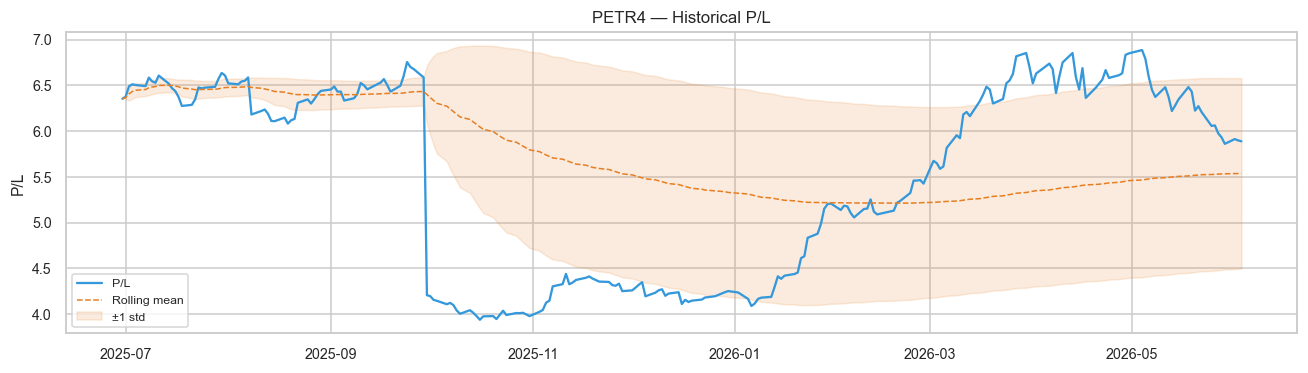

In [12]:

TICKER = 'PETR4'   # ← change to any B3 ticker

profile = orc.get_stock_profile(TICKER)
lf = profile['latest_fundamentals']
print(f'=== {TICKER} ===')
for k, v in lf.items():
    if k in METRIC_LABELS:
        print(f'  {METRIC_LABELS[k]:>15}: {v}')
print()
# Determine if any metric has a usable time-series Z (else hide that column)
_has_ts = any(r['time_series_zscore'] is not None for r in profile['zscores'])
# Sort by |CS Z| desc so the most extreme readings appear first
_rows = sorted(
    profile['zscores'],
    key=lambda r: abs(r['cross_sectional_zscore']) if r['cross_sectional_zscore'] is not None else -1,
    reverse=True,
)
for row in _rows:
    if row['time_series_zscore'] is None and row['cross_sectional_zscore'] is None:
        continue
    label = METRIC_LABELS.get(row['metric'], row['metric'])
    cs = f"{row['cross_sectional_zscore']:.2f}" if row['cross_sectional_zscore'] is not None else '  -- '
    if _has_ts:
        ts = f"{row['time_series_zscore']:.2f}" if row['time_series_zscore'] is not None else '  -- '
        print(f'  {label:>18}: TS={ts:>6}  CS={cs:>6}')
    else:
        print(f'  {label:>18}: CS={cs:>6}')

# Historical P/L chart
hist = orc.db.get_fundamental_snapshots(ticker=TICKER)
if not hist.empty and 'pl' in hist.columns and not hist['pl'].dropna().empty:
    hist['snapshot_date'] = pd.to_datetime(hist['snapshot_date'])
    h = hist[['snapshot_date', 'pl']].dropna().sort_values('snapshot_date')
    h['mean'] = h['pl'].expanding().mean()
    h['std']  = h['pl'].expanding().std()
    fig, ax = plt.subplots(figsize=(12, 3.5))
    ax.plot(h['snapshot_date'], h['pl'],   label='P/L',         color='#3498db', lw=1.5)
    ax.plot(h['snapshot_date'], h['mean'], label='Rolling mean', color='#e67e22', lw=1, ls='--')
    ax.fill_between(h['snapshot_date'], h['mean'] - h['std'], h['mean'] + h['std'],
                    alpha=0.15, color='#e67e22', label='±1 std')
    ax.set_title(f'{TICKER} — Historical P/L', fontsize=11)
    ax.set_ylabel('P/L'); ax.legend(fontsize=8)
    plt.tight_layout()
    plt.show()


In [13]:
# ⚠️  This cell runs the FULL pipeline — can take 15–30 min for all B3 stocks.
# Uncomment and run only when you want a complete refresh.

# summary = orc.run_full_pipeline(
#     fetch_prices=True,
#     compute_historical_metrics=True,
# )
# import pprint; pprint.pprint(summary)

---
## Intrinsic Value & Quality — the Graham / Buffett / Damodaran lens

The cells below go beyond statistical cheapness (Z-scores) and ask the questions a
value investor actually cares about:

1. **What is the business worth?** — a two-stage DCF on free cash flow → intrinsic value
   per share and **margin of safety** `(intrinsic − price) / intrinsic`.
2. **Is it a good business?** — a **quality** score (ROIC, ROE, margins, low debt) and a
   **moat** proxy (pricing power + capital efficiency).
3. **The master screen** — `screen_graham_buffett` blends all pillars into one
   `master_score`: discount to intrinsic value, growth, return on capital, low leverage,
   moat and quality.

> Run the valuation enrichment cell once per data refresh (it fetches cash-flow and
> dividend data per ticker from yfinance, so it is slow). It degrades gracefully — names
> without cash-flow data simply have no DCF.


In [ ]:
# ── Valuation enrichment: FCF → DCF intrinsic value + quality/moat scores ────
# Slow (per-ticker yfinance cash-flow + dividends). Run once per data refresh.
val_tickers = ibov_tickers   # IBOV only for speed & data quality
print(f'Computing FCF, DCF intrinsic value & margin of safety for {len(val_tickers)} tickers …')
n_val = orc.compute_valuation_metrics(val_tickers)
n_qual = orc.quality_scorer.compute_and_store()
print(f'✓ {n_val} valuation rows | {n_qual} quality-scored tickers | {orc.db.summary()}')


In [ ]:
# ── DCF intrinsic value & margin of safety ───────────────────────────────────
iv_rank = orc.get_intrinsic_value_ranking(top_n=TOP_N_RANKING)
if iv_rank.empty:
    print('No intrinsic-value data yet — run the valuation enrichment cell above.')
else:
    show = iv_rank.rename(columns={
        'ticker': 'Ticker', 'price': 'Preço', 'intrinsic_value': 'Valor Intrínseco',
        'margin_of_safety': 'Margem Segurança', 'fcf_per_share': 'FCF/Ação',
        'quality_score': 'Qualidade', 'moat_score': 'Moat',
    }).copy()
    show['Margem Segurança'] = (show['Margem Segurança'] * 100).round(1).astype(str) + '%'
    print(f'Top {len(show)} por margem de segurança (DCF, desconto {DISCOUNT_RATE:.0%} / '
          f'perpetuidade {TERMINAL_GROWTH:.0%})')
    display(show.round(2))


In [ ]:
# ── Quality & Moat scorecard ─────────────────────────────────────────────────
scores = orc.quality_scorer.compute_scores()
if scores.empty:
    print('No quality scores yet — run the valuation enrichment cell above.')
else:
    top_q = scores.head(TOP_N_RANKING).copy()
    fig, ax = plt.subplots(figsize=(10, max(3, 0.4 * len(top_q))))
    y = np.arange(len(top_q))
    ax.barh(y - 0.2, top_q['quality_score'], height=0.38, label='Qualidade', color='#2980b9')
    ax.barh(y + 0.2, top_q['moat_score'],    height=0.38, label='Moat',      color='#27ae60')
    ax.set_yticks(y); ax.set_yticklabels(top_q['ticker'])
    ax.invert_yaxis(); ax.set_xlim(0, 1)
    ax.set_xlabel('Score (0–1, percentil cross-sectional)')
    ax.set_title(f'Top {len(top_q)} — Qualidade do negócio & Moat (Buffett/Greenwald)', fontsize=11)
    ax.legend(loc='lower right', fontsize=8)
    plt.tight_layout(); plt.show()
    display(top_q[['ticker', 'sector', 'quality_score', 'moat_score']].round(3))


In [ ]:
# ── Master screen: Graham / Buffett / Damodaran quality-value ────────────────
# Blends 7 pillars into a single master_score: margin of safety, growth,
# return on capital, low leverage, moat, quality and cross-sectional cheapness.
master = orc.screen_graham_buffett(
    min_margin_of_safety=0.20,   # ≥20% discount to DCF intrinsic value
    min_quality=0.50,            # above-median business quality
    min_growth=0.0,              # non-negative growth Z
    top_n=TOP_N_RANKING,
)
if master.empty:
    print('No names pass the master screen yet (or valuation not computed). '
          'Run the enrichment cell, or loosen the thresholds.')
else:
    cols = ['ticker', 'price', 'intrinsic_value', 'margin_of_safety',
            'roic', 'debt_equity', 'quality_score', 'moat_score',
            'growth_score', 'master_score']
    out = master[[c for c in cols if c in master.columns]].copy()
    print(f'{len(out)} stocks pass the Graham/Buffett/Damodaran master screen')
    display(out.round(3))
